In [19]:

# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [20]:
df_da=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')]

<Axes: >

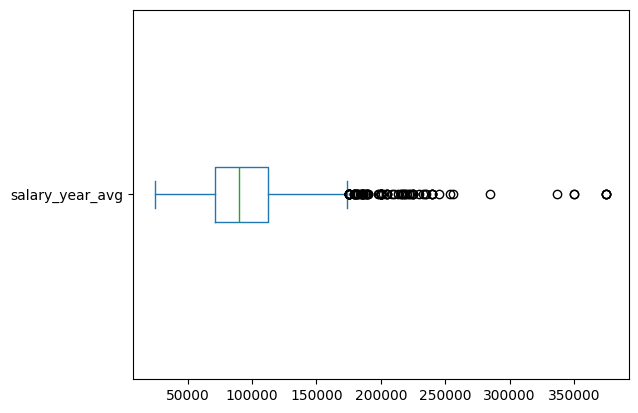

In [21]:
df_da['salary_year_avg'].plot(kind='box',vert=False)

In [23]:
df['job_title_short'].unique()
df=df[df['job_country']=='United States']
df=df.dropna(subset='salary_year_avg')

In [32]:
job_list=['Data Analyst','Data Engineer','Data Scientist']

In [28]:
hold=[df[df['job_title_short']==i]['salary_year_avg'] for i in job_list]

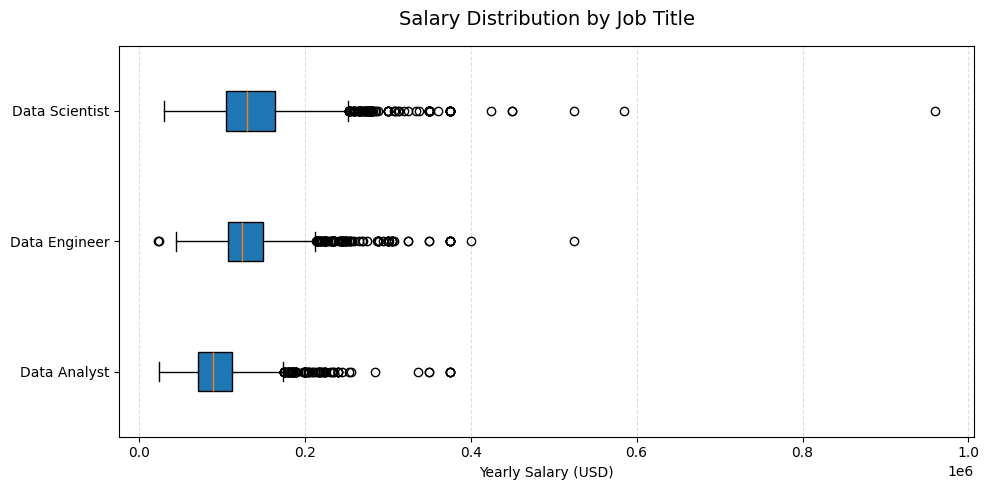

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

plt.boxplot(
    hold,
    tick_labels=job_list,   # labels replaces deprecated labels=
    vert=False,
    patch_artist=True
)

ax.set_title(
    'Salary Distribution by Job Title',
    fontsize=14,
    pad=15
)

ax.set_xlabel('Yearly Salary (USD)')
ax.set_ylabel('')

ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()